In [1]:
import importlib
import data
importlib.reload(data)
from data import load_and_preprocess

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datetime import timedelta
from torch.utils.data import DataLoader
import numpy as np
import os
from data import load_and_preprocess, LoadDataset, split_by_task
from util import calculate_metrics, evaluate_model, log_loss_csv, log_metrics_csv
import time

In [ ]:
directory = 'data'
min_length = 80_000
valid_dfs = {}

# Step 1: Load and filter files with enough data
for filename in os.listdir(directory):
    if filename.startswith('mm') and filename.endswith('.csv'):
        file_path = os.path.join(directory, filename)
        try:
            df = pd.read_csv(file_path, usecols=['ts', 'vrednost'], parse_dates=['ts'])
            df = df.sort_values('ts')
            df['vrednost'] = df['vrednost'].interpolate(method='linear', limit_direction='both')
            df = df.dropna(subset=['vrednost'])

            if len(df) >= min_length:
                df = df.rename(columns={'vrednost': filename})
                valid_dfs[filename] = df
                print(f"✅ Loaded {filename} with {len(df)} rows")
            else:
                print(f"⚠️ Skipped {filename} (only {len(df)} rows)")
        except Exception as e:
            print(f"❌ Error reading {filename}: {e}")

# Step 2: Determine common timestamp range
if not valid_dfs:
    print("❌ No datasets with sufficient length found.")
    exit()

start_times = [df['ts'].iloc[0] for df in valid_dfs.values()]
end_times = [df['ts'].iloc[-1] for df in valid_dfs.values()]
common_start = max(start_times)
common_end = min(end_times)

# Step 3: Trim and reindex each DataFrame
for name in list(valid_dfs):
    df = valid_dfs[name]
    trimmed = df[(df['ts'] >= common_start) & (df['ts'] <= common_end)].copy()

    if len(trimmed) < min_length:
        print(f"⚠️ Excluded {name} after trimming to common range ({len(trimmed)} rows)")
        del valid_dfs[name]
    else:
        # Fill missing timestamps hourly only for this DF
        full_index = pd.date_range(start=common_start, end=common_end, freq='h')
        trimmed = trimmed.set_index('ts').reindex(full_index)
        trimmed.index.name = 'ts'
        trimmed[name] = trimmed[name].interpolate(method='linear', limit_direction='both')
        valid_dfs[name] = trimmed.reset_index()
        print(f"✅ Trimmed & filled {name} to common hourly range: {len(trimmed)} rows")

# Step 4: Merge on 'ts'
if valid_dfs:
    merged_df = list(valid_dfs.values())[0]
    for name, df in list(valid_dfs.items())[1:]:
        merged_df = pd.merge(merged_df, df, on='ts', how='inner')

    merged_df = merged_df.sort_values('ts')
    merged_df.to_csv(os.path.join(directory, 'merged.csv'), index=False)
    print(f"✅ Merged file saved as '{os.path.join(directory, 'merged.csv')}' with shape {merged_df.shape}")
else:
    print("❌ No datasets remained after trimming to common range.")


✅ Loaded mm118648.csv with 168144 rows
✅ Loaded mm125431.csv with 132227 rows
✅ Loaded mm144644.csv with 128170 rows
✅ Loaded mm148296.csv with 125832 rows
✅ Loaded mm166942.csv with 119244 rows
✅ Loaded mm182972.csv with 147332 rows
✅ Loaded mm187195.csv with 129391 rows
✅ Loaded mm199762.csv with 121040 rows
✅ Loaded mm254.csv with 168125 rows
✅ Loaded mm3371.csv with 119625 rows
✅ Loaded mm41865.csv with 116527 rows
✅ Loaded mm45674.csv with 164728 rows
✅ Loaded mm4678.csv with 168181 rows
✅ Loaded mm57710.csv with 149971 rows
✅ Loaded mm65924.csv with 123811 rows
✅ Loaded mm72425.csv with 120999 rows
✅ Loaded mm79158.csv with 121019 rows
✅ Loaded mm9725.csv with 147348 rows
✅ Trimmed & filled mm118648.csv to common hourly range: 20269 rows
✅ Trimmed & filled mm125431.csv to common hourly range: 20269 rows
✅ Trimmed & filled mm144644.csv to common hourly range: 20269 rows
⚠️ Excluded mm148296.csv after trimming to common range (78378 rows)
⚠️ Excluded mm166942.csv after trimming to 

In [3]:
df = load_and_preprocess('data/merged.csv')
len(df[df['task_id'] == 1])

20269

C:\Users\janav\AppData\Local\Temp\ipykernel_19716\3173477347.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['train_loss_norm'] = (task_df['train_loss'] - train_min) / (train_max - train_min)
C:\Users\janav\AppData\Local\Temp\ipykernel_19716\3173477347.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['val_loss_norm'] = (task_df['val_loss'] - val_min) / (val_max - val_min)


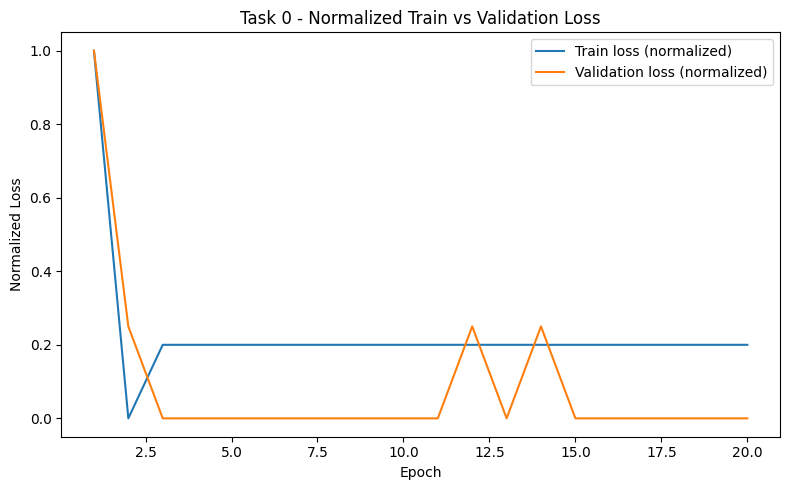

C:\Users\janav\AppData\Local\Temp\ipykernel_19716\3173477347.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['train_loss_norm'] = (task_df['train_loss'] - train_min) / (train_max - train_min)
C:\Users\janav\AppData\Local\Temp\ipykernel_19716\3173477347.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df['val_loss_norm'] = (task_df['val_loss'] - val_min) / (val_max - val_min)


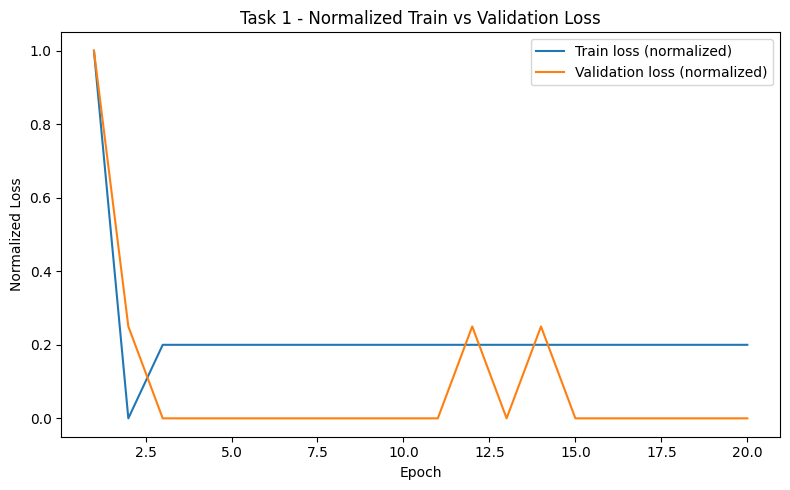

In [4]:
df = pd.read_csv('logs/training_log.csv')

# Loop over unique task_ids
for task_id in df['task_id'].unique():
    task_df = df[df['task_id'] == task_id]

    # Min-max normalize train and val loss
    train_min, train_max = task_df['train_loss'].min(), task_df['train_loss'].max()
    val_min, val_max = task_df['val_loss'].min(), task_df['val_loss'].max()

    task_df['train_loss_norm'] = (task_df['train_loss'] - train_min) / (train_max - train_min)
    task_df['val_loss_norm'] = (task_df['val_loss'] - val_min) / (val_max - val_min)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(task_df['epoch'], task_df['train_loss_norm'], label="Train loss (normalized)")
    plt.plot(task_df['epoch'], task_df['val_loss_norm'], label="Validation loss (normalized)")
    plt.title(f"Task {task_id} - Normalized Train vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [15]:
import torch
import numpy as np
import pandas as pd

def iterative_forecast_full(model, val_df, test_df, input_len, horizon, task_id, scaler, device):
    model.eval()
    preds_total = []

    # Task-specific validation and test sets
    val_task = val_df[val_df["task_id"] == task_id].copy()
    test_task = test_df[test_df["task_id"] == task_id].copy().reset_index(drop=True)

    # Starting history = last input_len from val
    history = val_task.iloc[-input_len:].copy()

    # We’ll walk through test set step by step
    steps = (len(test_task) - horizon) // horizon
    forecasted_len = steps * horizon
    y_true = test_task["vrednost"].iloc[:forecasted_len].values  # still scaled

    features = ["time", "day_of_year", "day_type"]

    for step in range(steps):
        # Pull the next horizon-sized chunk from test set
        future_rows = test_task.iloc[step * horizon : (step + 1) * horizon].copy()

        # Just reuse their features (already scaled)
        X_input = torch.tensor(future_rows[features].values, dtype=torch.float32).to(device)
        task_tensor = torch.tensor([task_id] * horizon, dtype=torch.long).to(device)

        # Predict
        G = model.compute_shared_basis(X_input)
        pred_scaled = model.predict_with_basis(G, task_tensor)
        pred_np = pred_scaled.cpu().numpy()
        pred_orig = scaler["target_scaler"].inverse_transform(pred_np)

        preds_total.extend(pred_orig.flatten().tolist())

        # Simulate feeding prediction back into the model
        for i in range(horizon):
            scaled_value = scaler["target_scaler"].transform([[pred_orig[i][0]]])[0][0]
            new_row = {
                "time": future_rows.iloc[i]["time"],
                "day_of_year": future_rows.iloc[i]["day_of_year"],
                "day_type": future_rows.iloc[i]["day_type"],
                "task_id": task_id,
                "vrednost": scaled_value
            }
            history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

        history = history[-input_len:]

    return np.array(y_true[:len(preds_total)]), np.array(preds_total)


In [6]:
def plot_data(y_true, y_pred):
    plt.figure(figsize=(30, 7))
    plt.plot(y_true, color='blue', linewidth=0.5, label='True Values (t+1)')
    plt.plot(y_pred, color='red', linewidth=0.5, label='Predicted Values (t+1)')
    plt.title("Forecast Step t+1: Predicted vs True")
    plt.xlabel("Time Step")
    plt.ylabel("Rescaled Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
val_ratio = 0.1
test_ratio = 0.3
FORECAST_LEN = 1
BATCH_SIZE = 64

df = load_and_preprocess('data/merged.csv')
train_df, val_df, test_df, scalers = split_by_task(df, val_ratio, test_ratio)

train_data = LoadDataset(train_df, horizon=FORECAST_LEN)
val_data = LoadDataset(val_df, horizon=FORECAST_LEN)
test_data = LoadDataset(test_df, horizon=FORECAST_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

In [8]:
model = torch.load('models/model_epoch_20.pt')

C:\Users\janav\AppData\Local\Temp\ipykernel_19716\1707764512.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('models/model_epoch_20.pt')


In [11]:
start_time = time.time()
y_true, y_pred, st_metrics = evaluate_model(model, test_loader, 'cuda', scalers, 'st')
end_time = time.time()
elapsed_time = end_time - start_time

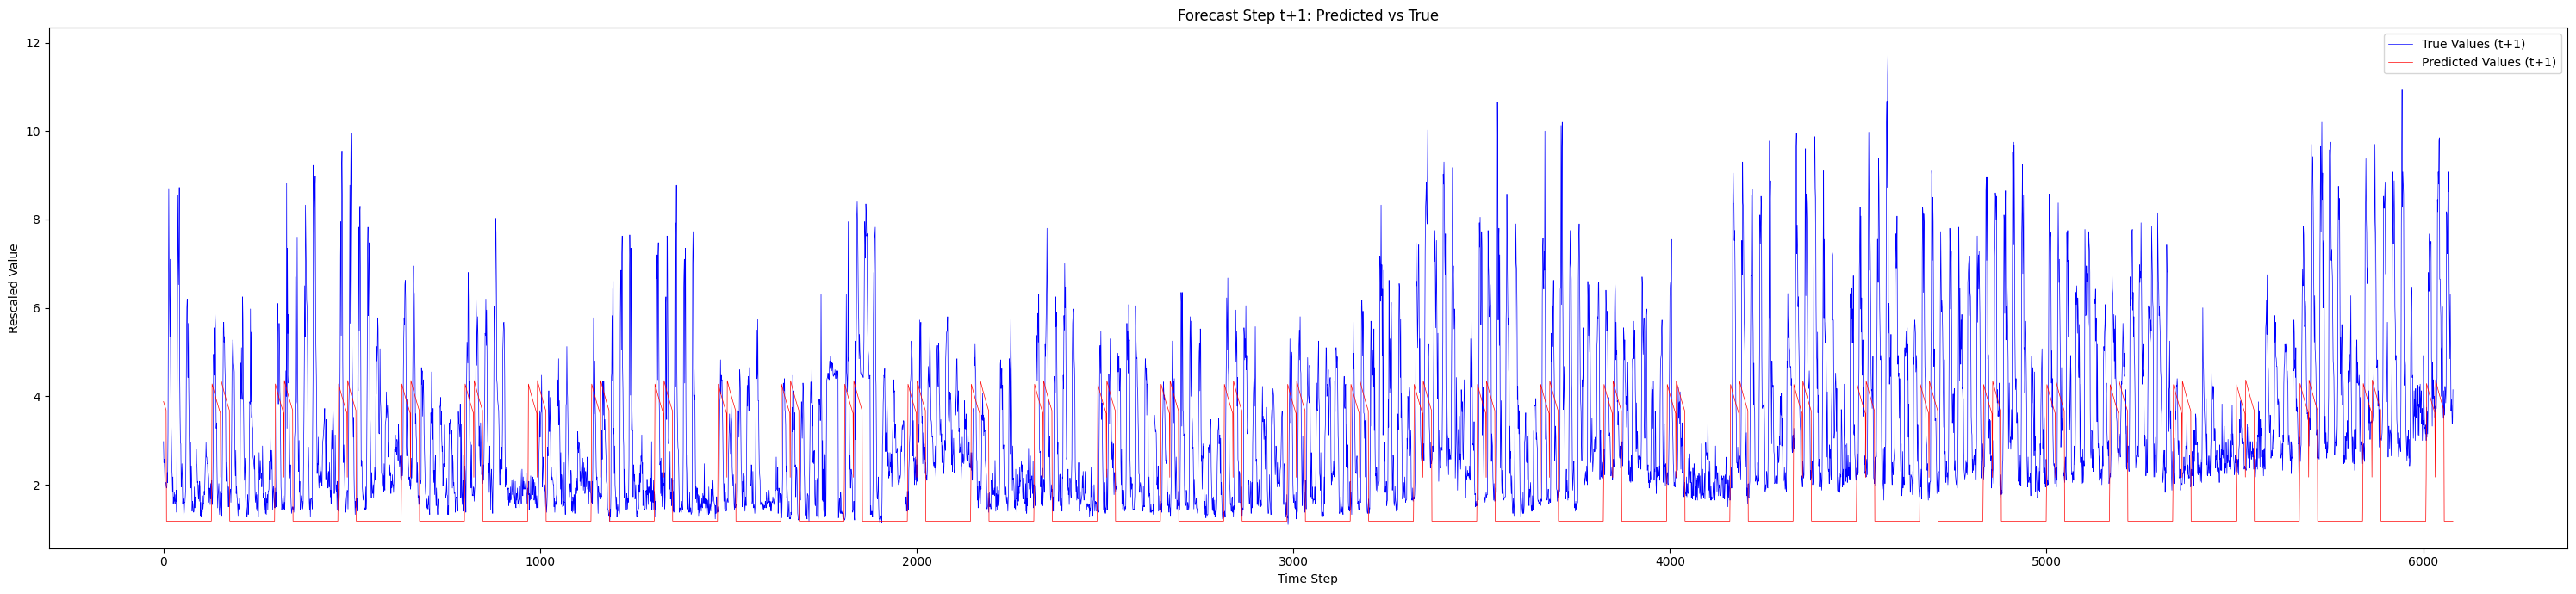

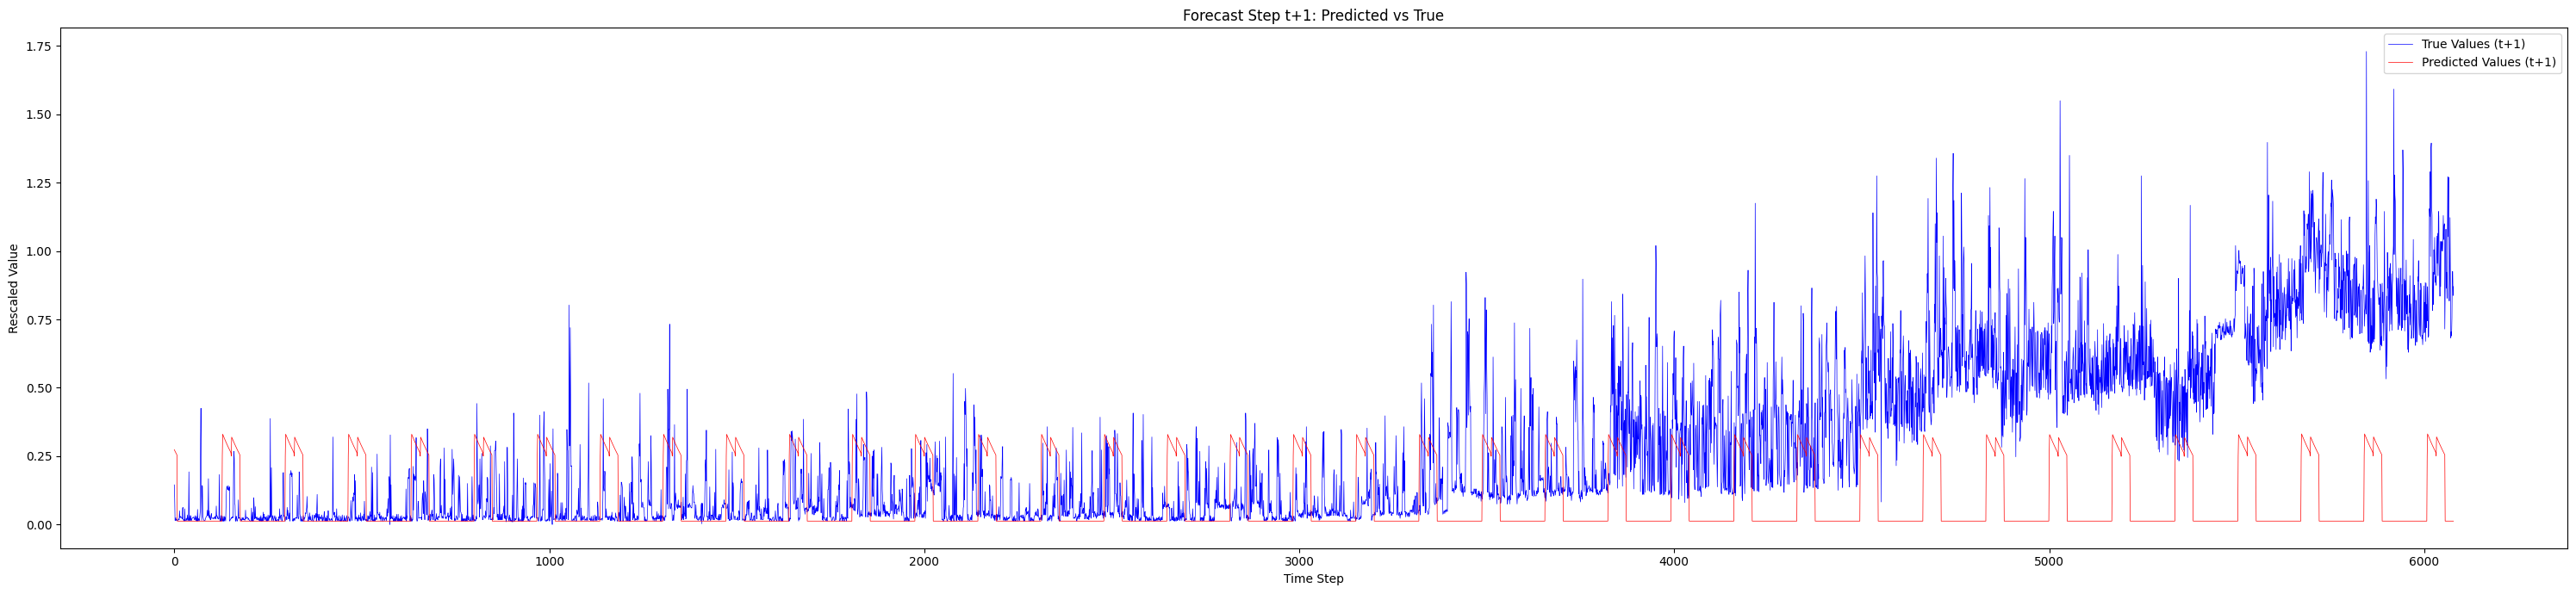

In [12]:
plot_data(y_true[0], y_pred[0])
plot_data(y_true[1], y_pred[1])

In [18]:
s0 = time.time()
_, y_auto_0 = iterative_forecast_full(model, val_df, test_df, input_len=24*14, horizon=FORECAST_LEN, task_id=0, scaler=scalers[0], device='cuda')
e0 = time.time()

s1 = time.time()
_, y_auto_1 = iterative_forecast_full(model, val_df, test_df, input_len=24*14, horizon=FORECAST_LEN, task_id=1, scaler=scalers[1], device='cuda')
e1 = time.time()

c:\Users\janav\.pyenv\pyenv-win\versions\3.10.5\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\janav\.pyenv\pyenv-win\versions\3.10.5\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\janav\.pyenv\pyenv-win\versions\3.10.5\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\janav\.pyenv\pyenv-win\versions\3.10.5\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\janav\.pyenv\pyenv-win\versions\3.10.5\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature n

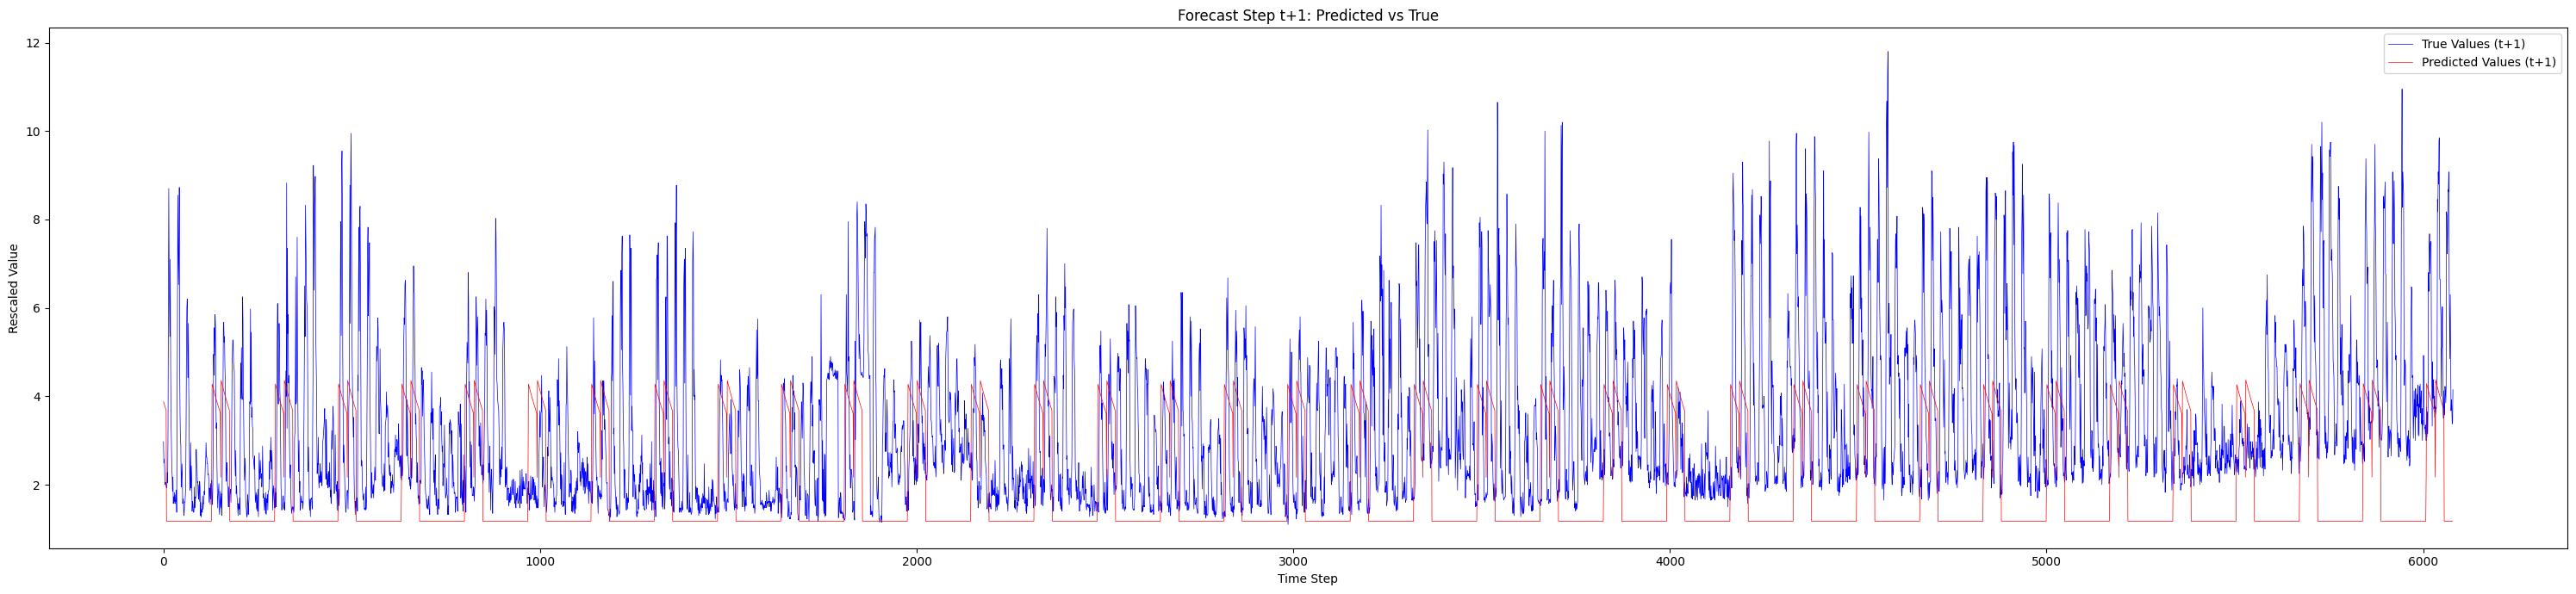

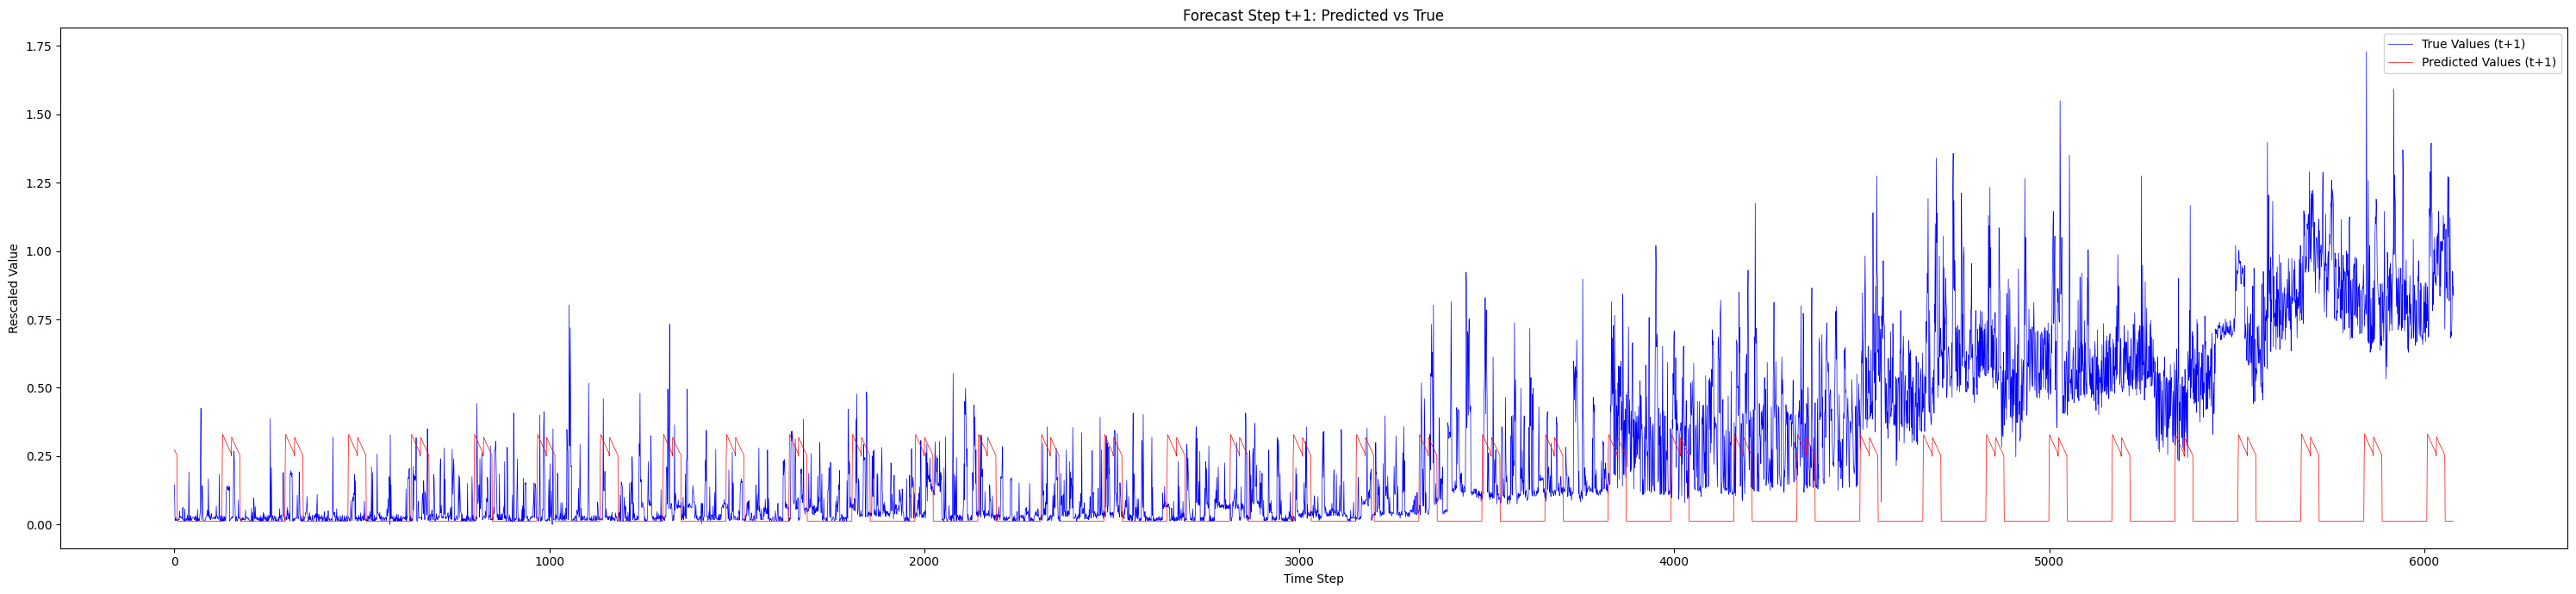

In [19]:
plot_data(y_true[0], y_auto_0)
plot_data(y_true[1], y_auto_1)

In [25]:
metrics_lt0 = calculate_metrics(y_true[0][:len(y_auto_0)], y_auto_0, e0 - s0, 'lt')
metrics_lt1 = calculate_metrics(y_true[1][:len(y_auto_1)], y_auto_1, e1 - s1, 'lt')
lt_metrics = {
    0: metrics_lt0, 
    1: metrics_lt1
}

In [26]:
def flatten_metrics(metrics_dict):
    return pd.DataFrame([
        {"task_id": task_id, **metrics}
        for task_id, metrics in metrics_dict.items()
    ])


In [27]:
results_df = pd.concat([
    flatten_metrics(st_metrics),
    flatten_metrics(lt_metrics)
], axis=0).reset_index(drop=True)

results_df.to_csv("logs/prediction_eval.csv", index=False)


In [29]:
all_pred_rows = []
y_auto = {
    0: y_auto_0,  # long-term
    1: y_auto_1
}

for task_id in y_true:
    n = len(y_auto[task_id])  # match long-term length
    all_pred_rows.append(pd.DataFrame({
        "task_id": [task_id] * n,
        "y_true": y_true[task_id][:n].ravel(),
        "y_st": y_pred[task_id][:n].ravel(),
        "y_lt": y_auto[task_id].ravel()
    }))

df_preds = pd.concat(all_pred_rows, axis=0).reset_index(drop=True)
df_preds.to_csv("logs/prediction_data.csv", index=False)
